In [2]:
!pip install pandas==2.2.2 numpy==1.26.4 \
sentence-transformers==2.7.0 torch==2.3.1 \
scikit-learn==1.4.2 matplotlib==3.8.4


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/159.8 MB ? eta -:--:--
   ---------------------------------------- 1.0/159.8 MB 10.1 MB/s eta 0:00:16
    --------------------------------------- 2.1/159.8 MB 4.7 MB/s eta 0:00:34
    --------------------------------------- 3.4/159.8 MB 5.3 MB/s eta 0:00:30
   - -------------------------------------- 4.7/159.8 MB 5.5 MB/s eta 0:00:29
   - -------------------------------------- 5.8/159.8 MB 5.4 MB/s eta 0:00:29
   - -------------------------------------- 6.8/159.8 MB 5.4 MB/s eta 0:00:29
   -- ------------------------------------- 8.1/159.8 MB 5.5 MB/s eta 0:00:28
   -- ------------------------------------- 9.4/159.8 MB 5.5 MB/s eta 0:00:28
   -- ------------------------------------- 10.2/159.8 MB 5.4 MB/s eta 0:00:28
   -- ------------------------------------- 10.5/159.8 MB 5.4 MB/s eta 0:00:28
   -- ------------------------------------- 10.5/159.8 MB 5.4 MB/s eta 0:00:28
   

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.5.1+cu121 requires torch==2.5.1+cu121, but you have torch 2.3.1 which is incompatible.
torchvision 0.20.1+cu121 requires torch==2.5.1+cu121, but you have torch 2.3.1 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
!pip install seaborn 


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
# 1️⃣ Import Library
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, roc_curve, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)


In [43]:
df = pd.read_csv("dataset_pairs.csv")
print("Jumlah data:", len(df))
print(df.head())

Jumlah data: 389
                                             title_1  \
0  hubungan sma kendari sepakbola lari negeri ket...   
1  timur kelas xi poli kesegaran jasmani siswa ip...   
2  timur permainan sepak hubungan kaki dribling s...   
3  tingkat belajar kabupaten hasil siswa kontribu...   
4  lempar lembing otot dengan poli sma pada kolak...   

                                          abstract_1  \
0  oleh permainan untuk secara kunci keguruan ilm...   
1  analisis sampel analisis kolaka tahun sebagian...   
2  digunakan yang timur kaki ini melakukan poli s...   
3  kunci pjok ulama v pembimbing untuk belajar me...   
4  polia kekuatan hipotesis dengan populas antara...   

                                             title_2  \
0  hubungan kecepatan lari dengan keterampilan dr...   
1  survei tingkat kesegaran jasmani siswa kelas x...   
2  hubungan koordinasi mata kaki dengan keterampi...   
3  kontribusi tingkat kesegaran jasmani terhadap ...   
4  hubungan kekuatan otot len

In [51]:
# 2️⃣ Hapus spasi ekstra dan ubah ke lowercase
df['title_1'] = df['title_1'].astype(str).str.strip().str.lower()
df['title_2'] = df['title_2'].astype(str).str.strip().str.lower()
df['abstract_1'] = df['abstract_1'].astype(str).str.strip().str.lower()
df['abstract_2'] = df['abstract_2'].astype(str).str.strip().str.lower()

# 3️⃣ Hapus data kosong atau null
df = df.dropna(subset=['title_1', 'title_2', 'abstract_1', 'abstract_2'])
df = df[(df['title_1'] != '') & (df['title_2'] != '')]

# 4️⃣ Hapus pasangan yang benar-benar identik (judul dan abstrak sama persis)
mask_same = (df['title_1'] == df['title_2']) & (df['abstract_1'] == df['abstract_2'])
same_count = mask_same.sum()
df = df[~mask_same]
print(f"Hapus {same_count} baris duplikat (judul & abstrak identik)")

# 5️⃣ Opsional: hapus pasangan dengan judul/abstrak yang terlalu pendek (<10 karakter)
mask_short = (df['title_1'].str.len() < 10) | (df['title_2'].str.len() < 10)
short_count = mask_short.sum()
df = df[~mask_short]
print(f"Hapus {short_count} baris karena terlalu pendek")

# 6️⃣ Heuristik auto-correction untuk label yang salah
# Jika judul & abstrak sama persis → plagiat = 1
# Jika sangat berbeda panjang (>70% selisih) → bukan plagiat = 0
def correct_label(row):
    if row['title_1'] == row['title_2'] and row['abstract_1'] == row['abstract_2']:
        return 1
    len_diff = abs(len(row['abstract_1']) - len(row['abstract_2'])) / (len(row['abstract_1']) + 1)
    if len_diff > 0.7:
        return 0
    return row['label']

df['label'] = df.apply(correct_label, axis=1)

# 7️⃣ Drop duplikat yang persis sama setelah pembersihan
df = df.drop_duplicates(subset=['title_1','title_2','abstract_1','abstract_2','label'])
print("Jumlah data akhir:", len(df))

# 8️⃣ Simpan hasil
df.to_csv("dataset_pairs_clean.csv", index=False)
print("\n✅ Dataset bersih disimpan ke dataset_pairs_clean.csv")

Hapus 0 baris duplikat (judul & abstrak identik)
Hapus 0 baris karena terlalu pendek
Jumlah data akhir: 389

✅ Dataset bersih disimpan ke dataset_pairs_clean.csv


In [52]:
# Load dataset bersih
df = pd.read_csv("dataset_pairs_clean.csv")

# Cek proporsi label
print("Distribusi label:")
print(df['label'].value_counts(normalize=True))

Distribusi label:
label
0    0.501285
1    0.498715
Name: proportion, dtype: float64


In [53]:
# Gabungkan teks
df['text_1'] = df['title_1'] + ". " + df['abstract_1']
df['text_2'] = df['title_2'] + ". " + df['abstract_2']

# Gunakan model cepat untuk analisis
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

e:\Flutter\saskia\check-plagiat\venv\lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches: 100%|██████████| 13/13 [00:34<00:00,  2.65s/it]


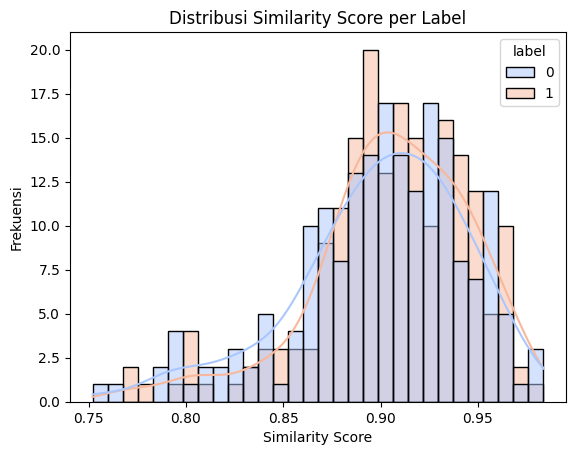


📊 Rata-rata Similarity per Label:
       count      mean       std       min       25%       50%       75%  \
label                                                                      
0      195.0  0.899759  0.044304  0.751999  0.875374  0.904736  0.930805   
1      194.0  0.905722  0.040604  0.768005  0.886980  0.909153  0.934923   

            max  
label            
0      0.983713  
1      0.982681  


In [54]:
# Encode teks
emb1 = model.encode(df['text_1'].tolist(), convert_to_tensor=True, show_progress_bar=True)
emb2 = model.encode(df['text_2'].tolist(), convert_to_tensor=True, show_progress_bar=True)

# Hitung cosine similarity
similarities = util.cos_sim(emb1, emb2)
df['similarity_score'] = [float(similarities[i][i]) for i in range(len(df))]

# Plot distribusi similarity berdasarkan label
sns.histplot(df, x='similarity_score', hue='label', bins=30, kde=True, palette='coolwarm')
plt.title("Distribusi Similarity Score per Label")
plt.xlabel("Similarity Score")
plt.ylabel("Frekuensi")
plt.show()

# Lihat statistik rata-rata dan sebaran per label
print("\n📊 Rata-rata Similarity per Label:")
print(df.groupby('label')['similarity_score'].describe())

In [44]:
# ===============================================
# 3️⃣ Advanced Text Cleaning
# ===============================================
def clean_text_advanced(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[^a-z0-9., ]', '', text)
    stopwords = [
        'penelitian', 'dalam', 'untuk', 'yang', 'dapat', 'ini', 'dengan',
        'adalah', 'pada', 'oleh', 'dari', 'hasil', 'menunjukkan',
        'dan', 'sebagai', 'terhadap'
    ]
    for sw in stopwords:
        text = re.sub(r'\b' + sw + r'\b', '', text)
    return text.strip()

for col in ['title_1', 'title_2', 'abstract_1', 'abstract_2']:
    df[col] = df[col].apply(clean_text_advanced)

In [45]:
# ===============================================
# 4️⃣ Load Model (lebih stabil untuk dataset kecil)
# ===============================================
model_name = 'sentence-transformers/distiluse-base-multilingual-cased-v2'
print(f"🚀 Loading model: {model_name}")
model = SentenceTransformer(model_name)


🚀 Loading model: sentence-transformers/distiluse-base-multilingual-cased-v2


e:\Flutter\saskia\check-plagiat\venv\lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [46]:
# ===============================================
# 5️⃣ Encode Title dan Abstract
# ===============================================
title_emb1 = model.encode(df['title_1'].tolist(), convert_to_tensor=True, show_progress_bar=True)
title_emb2 = model.encode(df['title_2'].tolist(), convert_to_tensor=True, show_progress_bar=True)
abs_emb1 = model.encode(df['abstract_1'].tolist(), convert_to_tensor=True, show_progress_bar=True)
abs_emb2 = model.encode(df['abstract_2'].tolist(), convert_to_tensor=True, show_progress_bar=True)


Batches: 100%|██████████| 13/13 [00:41<00:00,  3.22s/it]


In [47]:
# ===============================================
# 6️⃣ Hitung Cosine Similarity (S-BERT)
# ===============================================
title_sim = util.cos_sim(title_emb1, title_emb2)
abs_sim = util.cos_sim(abs_emb1, abs_emb2)
df['bert_title_sim'] = [float(title_sim[i][i]) for i in range(len(df))]
df['bert_abs_sim'] = [float(abs_sim[i][i]) for i in range(len(df))]
df['bert_score'] = 0.7 * df['bert_title_sim'] + 0.3 * df['bert_abs_sim']

In [48]:

# ===============================================
# 7️⃣ TF-IDF Similarity (literal match)
# ===============================================
tfidf = TfidfVectorizer(max_features=2000)
tfidf_emb = tfidf.fit_transform(df['abstract_1'].tolist() + df['abstract_2'].tolist())
split = len(df)
tfidf_sim = cosine_similarity(tfidf_emb[:split], tfidf_emb[split:])
df['tfidf_score'] = [float(tfidf_sim[i][i]) for i in range(len(df))]

In [49]:
# ===============================================
# 8️⃣ Gabungkan jadi Hybrid Score
# ===============================================
df['hybrid_score'] = 0.7 * df['bert_score'] + 0.3 * df['tfidf_score']

# ===============================================
# 9️⃣ Normalisasi Skor dengan Min-Max Scaling
# ===============================================
scaler = MinMaxScaler()
df['hybrid_score_norm'] = scaler.fit_transform(df[['hybrid_score']])


🎯 Threshold optimal (ROC): 0.806

Classification Report (Auto Threshold):

              precision    recall  f1-score   support

           0       0.52      0.92      0.66       195
           1       0.63      0.13      0.22       194

    accuracy                           0.53       389
   macro avg       0.58      0.53      0.44       389
weighted avg       0.58      0.53      0.44       389

AUC Score: 0.487

🔧 Best Threshold (Manual Search): 0.6 | F1: 0.502

Classification Report (Best Manual Threshold):

              precision    recall  f1-score   support

           0       0.49      0.45      0.47       195
           1       0.49      0.52      0.50       194

    accuracy                           0.49       389
   macro avg       0.49      0.49      0.49       389
weighted avg       0.49      0.49      0.49       389

AUC Score: 0.487


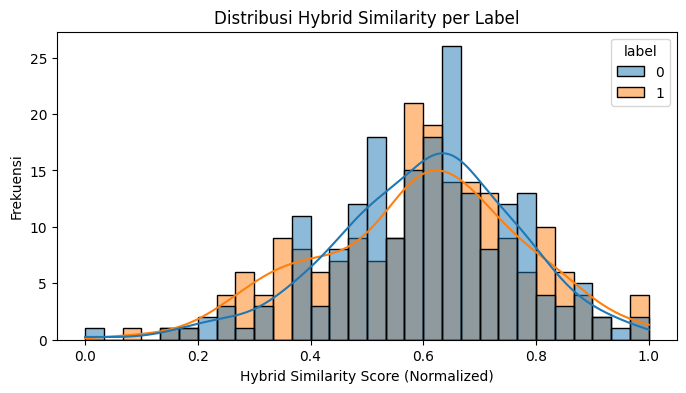

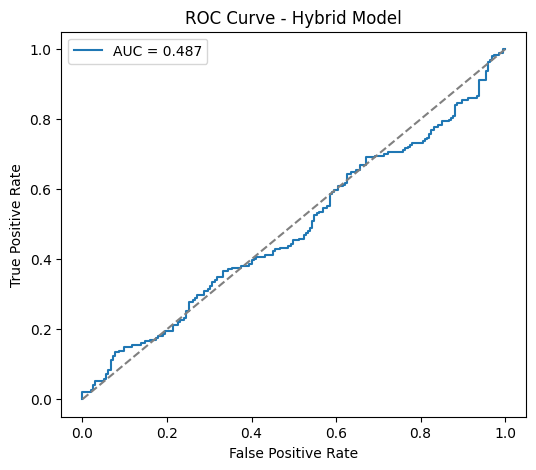

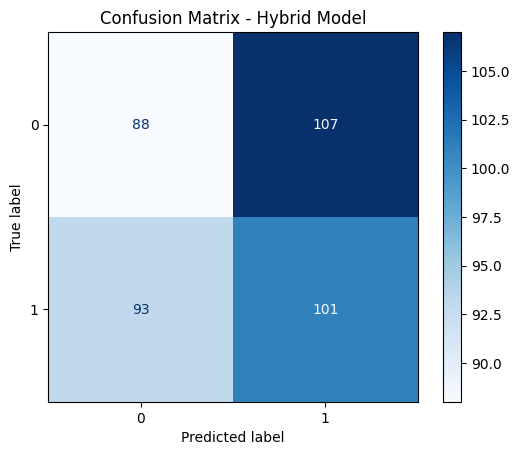

In [50]:
# ===============================================
# 🔟 Cari Threshold Otomatis via ROC
# ===============================================
fpr, tpr, thresholds = roc_curve(df['label'], df['hybrid_score_norm'])
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("🎯 Threshold optimal (ROC):", round(optimal_threshold, 3))

# ===============================================
# 11️⃣ Evaluasi Otomatis (Threshold ROC)
# ===============================================
preds_auto = (df['hybrid_score_norm'] >= optimal_threshold).astype(int)
print("\nClassification Report (Auto Threshold):\n")
print(classification_report(df['label'], preds_auto))
print("AUC Score:", round(roc_auc_score(df['label'], df['hybrid_score_norm']), 3))

# ===============================================
# 12️⃣ Cari Threshold Terbaik (Manual F1)
# ===============================================
best_f1, best_t = 0, 0
for t in np.arange(0.6, 0.95, 0.01):
    preds = (df['hybrid_score_norm'] >= t).astype(int)
    f1 = f1_score(df['label'], preds)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print(f"\n🔧 Best Threshold (Manual Search): {round(best_t,3)} | F1: {round(best_f1,3)}")

# ===============================================
# 13️⃣ Evaluasi Ulang (Threshold Manual)
# ===============================================
preds_best = (df['hybrid_score_norm'] >= best_t).astype(int)
print("\nClassification Report (Best Manual Threshold):\n")
print(classification_report(df['label'], preds_best))
print("AUC Score:", round(roc_auc_score(df['label'], df['hybrid_score_norm']), 3))

# ===============================================
# 14️⃣ Visualisasi Distribusi Skor & ROC
# ===============================================
plt.figure(figsize=(8,4))
sns.histplot(df, x='hybrid_score_norm', hue='label', bins=30, kde=True)
plt.title("Distribusi Hybrid Similarity per Label")
plt.xlabel("Hybrid Similarity Score (Normalized)")
plt.ylabel("Frekuensi")
plt.show()

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(df['label'], df['hybrid_score_norm']):.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hybrid Model")
plt.legend()
plt.show()

# ===============================================
# 15️⃣ Confusion Matrix
# ===============================================
cm = confusion_matrix(df['label'], preds_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Hybrid Model")
plt.show()

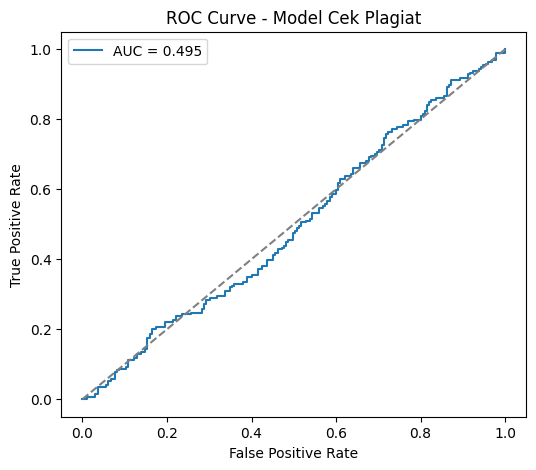

In [41]:
# ===============================================
# 11️⃣ Visualisasi ROC Curve
# ===============================================
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(df['label'], df['score_adjusted']):.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Cek Plagiat")
plt.legend()
plt.show()